# 01 — Data Audit & EDA
NYC Airbnb Open Data (2019) — CSE437 Project

**Goal of this notebook:** load the raw data, audit missingness and outliers,
compute descriptive statistics, and run an inferential test (ANOVA/t-test)
comparing price across boroughs. No cleaning happens here — that's Notebook 02.
This notebook just establishes *what's wrong* with the data, with evidence.

In [18]:
import sys, os

# find project root regardless of whether cwd is the project root or notebooks/
cwd = os.getcwd()
project_root = os.path.dirname(cwd) if os.path.basename(cwd) == 'notebooks' else cwd

sys.path.append(project_root)
sys.path.append(os.path.join(project_root, 'src'))

from utils import *  # matches the utils.py I gave you (flat module, not a package)

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load data

In [20]:
from src.utils import load_raw_data
df = load_raw_data()
print(df.shape)
df.head()

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

## 2. Missingness audit
Record exact counts/percentages — this is the evidence required by the
project rubric ("with evidence of what changed") before any cleaning.

In [22]:
missingness_report(df)

,missing_count,missing_pct
reviews_per_month,10052,20.56
last_review,10052,20.56
host_name,21,0.04
name,16,0.03


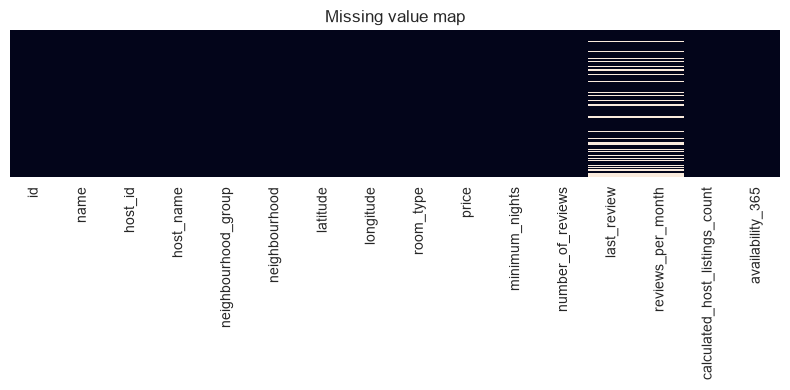

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, ax=ax)
ax.set_title('Missing value map')
plt.tight_layout()
plt.savefig('../figures/missingness_map.png', dpi=150)
plt.show()

## 3. Outlier audit
Check `price` and `minimum_nights` using the IQR method. Don't remove
anything yet — just quantify how many rows are affected and inspect them.

In [10]:
for col in ['price', 'minimum_nights']:
    mask = flag_outliers_iqr(df, col)
    lower, upper = iqr_outlier_bounds(df[col])
    print(f"{col}: bounds=({lower:.1f}, {upper:.1f}), outliers={mask.sum()} ({mask.mean()*100:.2f}%)")

price: bounds=(-90.0, 334.0), outliers=2972 (6.08%)
minimum_nights: bounds=(-5.0, 11.0), outliers=6607 (13.51%)


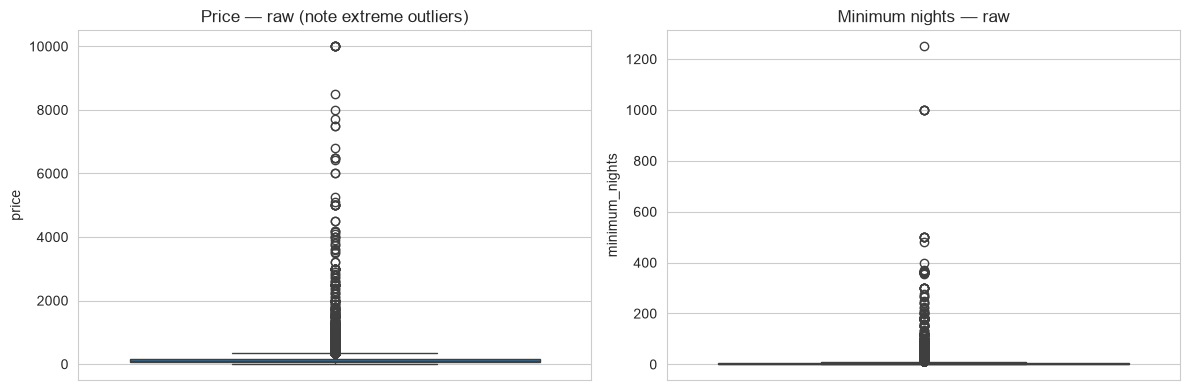

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df['price'], ax=axes[0])
axes[0].set_title('Price — raw (note extreme outliers)')
sns.boxplot(y=df['minimum_nights'], ax=axes[1])
axes[1].set_title('Minimum nights — raw')
plt.tight_layout()
plt.savefig('../figures/outlier_boxplots_raw.png', dpi=150)
plt.show()

In [12]:
print("Zero-price listings:", (df['price'] == 0).sum())
print("Price > $2000:", (df['price'] > 2000).sum())
print("Minimum nights > 365:", (df['minimum_nights'] > 365).sum())
df[df['price'] == 0][['name', 'neighbourhood_group', 'room_type', 'price']].head()

Zero-price listings: 11
Price > $2000: 86
Minimum nights > 365: 14


,name,neighbourhood_group,room_type,price
23161,"Huge Brooklyn Brownstone Living, Close to it all.",Brooklyn,Private room,0
25433,★Hostel Style Room | Ideal Traveling Buddies★,Bronx,Private room,0
25634,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",Brooklyn,Private room,0
25753,"Sunny, Quiet Room in Greenpoint",Brooklyn,Private room,0
25778,Modern apartment in the heart of Williamsburg,Brooklyn,Entire home/apt,0


## 4. Descriptive statistics
Required by the rubric. Cover both numeric summary stats and categorical
distributions.

In [13]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [14]:
for col in ['neighbourhood_group', 'room_type']:
    print(df[col].value_counts(normalize=True).round(3) * 100)
    print()

neighbourhood_group
Manhattan        44.3
Brooklyn         41.1
Queens           11.6
Bronx             2.2
Staten Island     0.8
Name: proportion, dtype: float64

room_type
Entire home/apt    52.0
Private room       45.7
Shared room         2.4
Name: proportion, dtype: float64



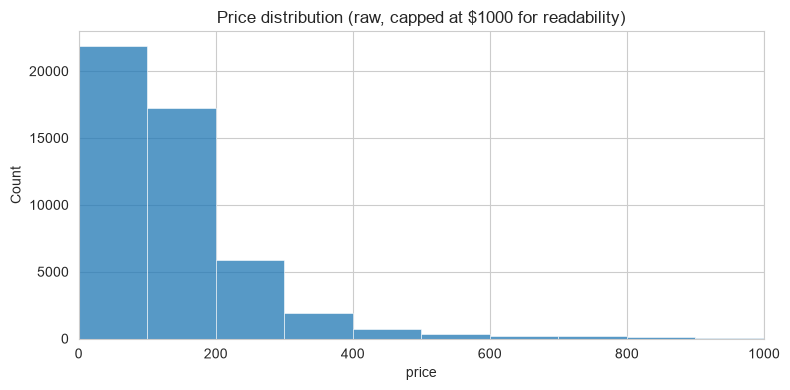

Skewness: 19.118938995046033


In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x='price', bins=100, ax=ax)
ax.set_xlim(0, 1000)
ax.set_title('Price distribution (raw, capped at $1000 for readability)')
plt.tight_layout()
plt.savefig('../figures/price_distribution_raw.png', dpi=150)
plt.show()

print("Skewness:", df['price'].skew())

## 5. Inferential statistics — does price differ by borough?
Syllabus Week 10 requires inferential, not just descriptive, statistics.
One-way ANOVA tests whether mean price differs significantly across the
five `neighbourhood_group` categories.

One-way ANOVA: F=354.99, p=7.72e-302


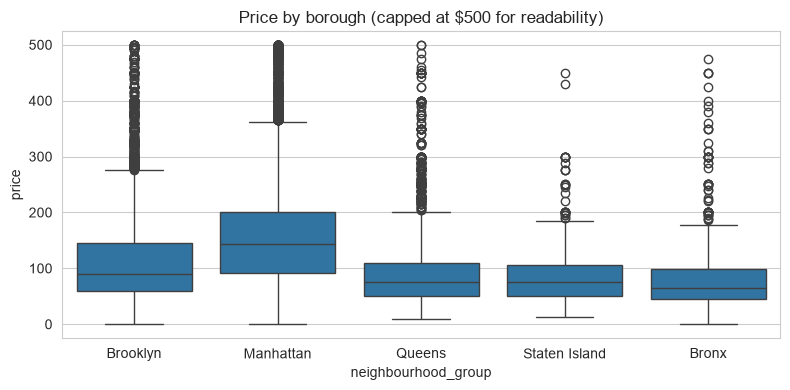

In [16]:
groups = [g['price'].values for _, g in df.groupby('neighbourhood_group')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA: F={f_stat:.2f}, p={p_val:.2e}")

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df[df['price'] < 500], x='neighbourhood_group', y='price', ax=ax)
ax.set_title('Price by borough (capped at $500 for readability)')
plt.tight_layout()
plt.savefig('../figures/price_by_borough.png', dpi=150)
plt.show()

## 6. Correlation overview (numeric features)
Informs feature engineering in Notebook 03 — not doing PCA/RFE here, just
a first look.

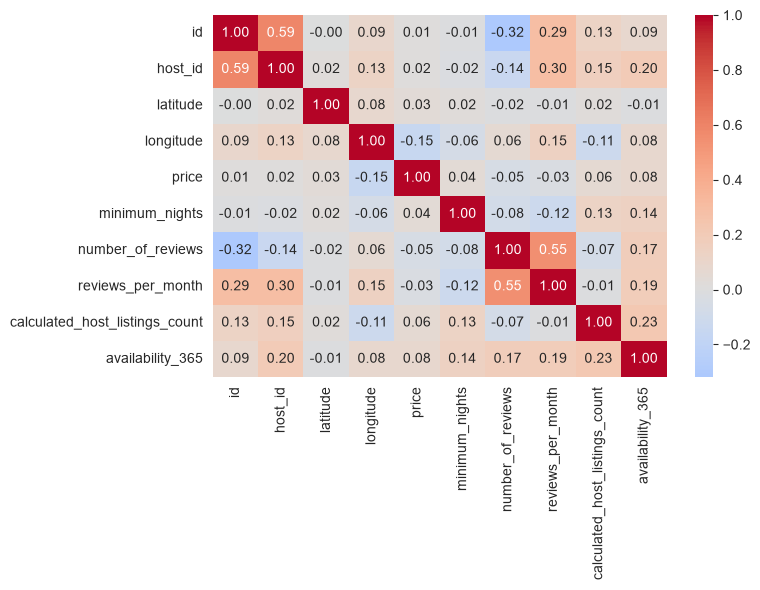

In [17]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
plt.tight_layout()
plt.savefig('../figures/correlation_heatmap_raw.png', dpi=150)
plt.show()